# Mother Machine — Medium Switch Analysis

This notebook analyses **gene expression switch dynamics** in mother machine experiments.
It is designed for experiments where cells undergo a switch in gene expression state during
the observation window, and you want to characterise:

- How long each expression state lasts (**switch cycle length**)
- Whether **top-pole cells** (at the closed end of each chamber) behave differently from all cells
- How long cells take to switch after a given time point (**division time analysis**)

**Analysis stages**
1. Load and filter the experiment
2. Compute growth rates and convert to per-hour units
3. Align replicates to a shared time axis
4. Identify switch cycles and rank cells by position in the chamber
5. Filter to top-pole cells and visualise switch dynamics
6. Division time analysis — time remaining until next switch
7. Filter bad baseline cells - remove cells that are already inactive during baseline
8. Lag time: deviation from baseline division timing

> **Before you start:** save your `FluidExperiment` to HDF5 (e.g. `experiment.save()`) and
> make sure the metadata contains a `group` column and the tracking data contains a `chamber`
> column that identifies the microfluidic chamber for each cell.

In [1]:
# ─── Paths ────────────────────────────────────────────────────────────────────
PATH = "/Users/lukasv/DATA/midap/Anna_mothermachine/experiment_rawwithmeta.h5"  # saved FluidExperiment HDF5 file

# ─── Experiment layout ────────────────────────────────────────────────────────
ID_COLUMN       = "trackID"  # column that uniquely identifies each cell track
LINEAGE_COLUMN  = "lineageID" # column that uniquely identifies each lineage
FRAME_COLUMN    = "frame" # column that identifies frames
GROUP_COLUMN    = "group" # metadata column that identifies the grouping variable
FRAMES_PER_HOUR = 12         # imaging frequency: frames captured per hour

# ─── Filtering ────────────────────────────────────────────────────────────────
MIN_OCCURENCES  = 10   # discard tracks shorter than this many frames

# ─── Growth rate ──────────────────────────────────────────────────────────────
GROWTH_RATE_INTEGRATION = 5  # symmetric window width (frames) for slope estimation

# ─── Frame alignment ──────────────────────────────────────────────────────────
# Per-group frame shift (in frames) so t = 0 is the same biological moment
# in every replicate. Keys must match values in the "group" metadata column.
OFFSETS = {
    "WT":    0,
    "dlacI": 0,
}

# ─── Lag time ────────────────────────────────────────────────────────────────
# Frame (in hours) that separates baseline from posterior for lag time calculation.
# All tracks last observed before this value form the per-lineage reference.
BOUNDARY_TIME   = 5.0  # set to the hour when the medium switch begins
BASELINE_MAX_CYCLE = 1.0  # remove baseline tracks longer than this (hours); raises suspicion of stalled/impaired cells

# ─── Survival analysis ────────────────────────────────────────────────────────
# Snapshot times (hours) at which to evaluate the time-to-switch distribution.
# Choose values within the experiment window where both groups are well represented.
START_TIMES = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# ─── Visualisation ────────────────────────────────────────────────────────────
CHAMBER_OFFSET = 50  # pixel gap added between chambers in XY scatter (cosmetic only)

## 1 — Load data

`FluidExperiment.load()` reads all positions and channels from the HDF5 file.
`print(experiment)` gives a compact overview of positions, channels, frame counts,
and metadata columns — use it to confirm the data loaded correctly.

In [2]:
from fluid_experiment.fluid_experiment import FluidExperiment

experiment = FluidExperiment.load(PATH)
print(experiment)

Successfully loaded experiment with data from 18 positions and 1 color channels
FluidExperiment with name: experiment
Path: /Volumes/G-MasterData4/Mother Machine Tiffs/MM_20260512/for analysis
18 positions: pos2, pos4, pos5, pos6, pos7, pos8, pos10, pos11, pos12, pos13, pos14, pos15, pos16, pos18, pos19, pos20, pos21, pos23
1 color channels: gfp
length of experiment is consistent: 224
Experiment has metadata:
          device_channel  experiment  group position
position                                            
pos2                 NaN  experiment     WT     pos2
pos4                 NaN  experiment     WT     pos4
pos5                 NaN  experiment     WT     pos5
pos6                 NaN  experiment     WT     pos6
pos7                 NaN  experiment     WT     pos7
pos8                 NaN  experiment  dlacZ     pos8
pos10                NaN  experiment  dlacZ    pos10
pos11                NaN  experiment  dlacZ    pos11
pos12                NaN  experiment  dlacZ    pos12
pos1

## 2 — Filter and compute growth rate

**Why filter by track length?**  
Tracks that appear for very few frames are unreliable: there are not enough data points
to estimate growth rate or assign a switch cycle. We keep only tracks that persist for
at least `MIN_OCCURENCES` consecutive frames.

**Growth rate calculation**  
Cell length grows exponentially. Log-transforming `major_axis_length` makes this growth
linear, so the slope equals the specific growth rate. We estimate the slope within a
symmetric window of `GROWTH_RATE_INTEGRATION` frames around each time point, then
multiply by `FRAMES_PER_HOUR` to express rates in *per-hour* units.

In [3]:
#OPTIONAL: align groups by correcting for technical offset (i.e different switch times)
# Shift frames so t = 0 is the same biological moment across all replicates
experiment.apply_offset_correction(
    OFFSETS, by_group=GROUP_COLUMN, frame_column=FRAME_COLUMN, out_column=FRAME_COLUMN
)

# Trim to the frame window shared by all positions
experiment.align_frames(frame_column=FRAME_COLUMN, out_column=FRAME_COLUMN)

# Remove lineages too short for reliable analysis
experiment.filter_data(column=LINEAGE_COLUMN, min_occurences=MIN_OCCURENCES)

# Log-transform cell length — makes exponential growth linear
experiment.calculate_transform_data("major_axis_length", postfix="_log")

# Estimate growth rate as slope of log-length within a rolling window
experiment.calculate_growth_rate(
    integration_window=GROWTH_RATE_INTEGRATION,
    id_column=ID_COLUMN,
    value_column="major_axis_length_log",
    growth_rate_column="growth_rate",
)

# Scale growth rate from per-frame to per-hour
experiment.calculate_transform_data(
    column="growth_rate",
    postfix="_fixed",
    custom_function=lambda x: FRAMES_PER_HOUR * x,
)

Aligning all positions to shared frame range [0, 224], written as [0, 224] in 'frame'
Filtering out lineageID with less than 10 occurences
Filtering channel gfp at position pos2:
Filtering channel gfp at position pos4:
Filtering channel gfp at position pos5:
Filtering channel gfp at position pos6:
Filtering channel gfp at position pos7:
Filtering channel gfp at position pos8:
Filtering channel gfp at position pos10:
Filtering channel gfp at position pos11:
Filtering channel gfp at position pos12:
Filtering channel gfp at position pos13:
Filtering channel gfp at position pos14:
Filtering channel gfp at position pos15:
Filtering channel gfp at position pos16:
Filtering channel gfp at position pos18:
Filtering channel gfp at position pos19:
Filtering channel gfp at position pos20:
Filtering channel gfp at position pos21:
Filtering channel gfp at position pos23:
Calculate growth_rate for trackID measured with major_axis_length_log over an integration window of 5


## 3 — Align replicates and convert to hours

Replicates are often started at slightly different absolute times.
`apply_offset_correction` shifts each group's frame index by the corresponding `OFFSETS`
value, so that all positions share the same t = 0 reference point.
`align_frames` then trims every position to the frame window that is covered by *all*
positions, so no group contributes data outside the shared observation period.

Finally, we convert integer frame numbers to hours by dividing by `FRAMES_PER_HOUR`
and store the result in a new column `time_hour`. Every downstream plot will use
`time_hour` on the x-axis so that results are immediately interpretable.

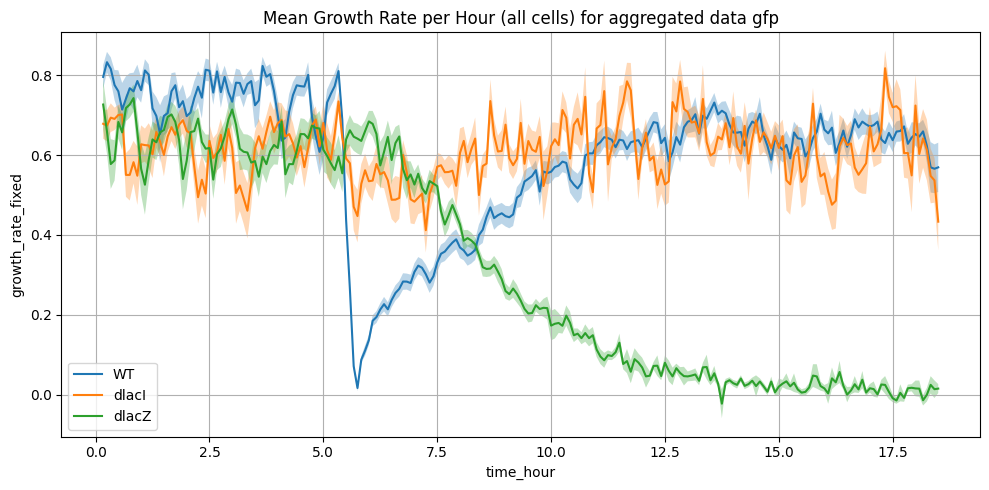

In [4]:
# Convert frame index to hours
experiment.calculate_transform_data(
    column=FRAME_COLUMN,
    postfix="_rescaled",
    custom_function=lambda x: x / FRAMES_PER_HOUR,
)
experiment.rename_data_column("frame_rescaled", "time_hour")

# Sanity check: growth rates should look consistent across groups after alignment
experiment.plot_rates(
    "growth_rate_fixed",
    frame_column="time_hour",
    group_by=GROUP_COLUMN,
    flip_grouping=True,
    title="Mean Growth Rate per Hour (all cells)",
)

## 4 — Identify switch cycles and rank cells by chamber position

### Switch cycle length
In this experiment each `trackID` represents a cell in a single gene-expression state,
bounded by the previous and next switch event. The *switch cycle length* is therefore
simply the total time the `trackID` is observed:

```
last_switch         = earliest time_hour for this (trackID, chamber) combination
next_switch         = latest   time_hour for this (trackID, chamber) combination
switch_cycle_length = next_switch - last_switch
```

`calculate_grouped_metric` computes these statistics per (trackID, chamber) group and
broadcasts them as new row-level columns, so every row carries both switch boundaries.

### Top-pole cells
Mother machine chambers have a **closed end** and an **open end**. The cell at the
closed end — the *top-pole cell* — has the longest uninterrupted history in the chamber
and experiences the most stable microenvironment. Switch dynamics are most clearly
measured in top-pole cells.

We identify the top-pole cell at each frame by ranking cells within each
(frame, chamber) group by their x-coordinate. **Run the QC plot below first** to confirm
that low x corresponds to the closed end in your data: lineages should drift slowly from
low to high x as cells grow out toward the open end.  
If the drift goes the other way, set `ascending=False` in `calculate_grouped_rank`.

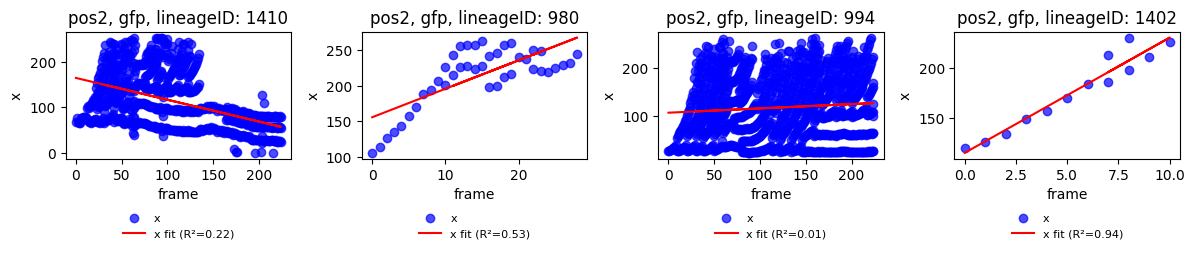

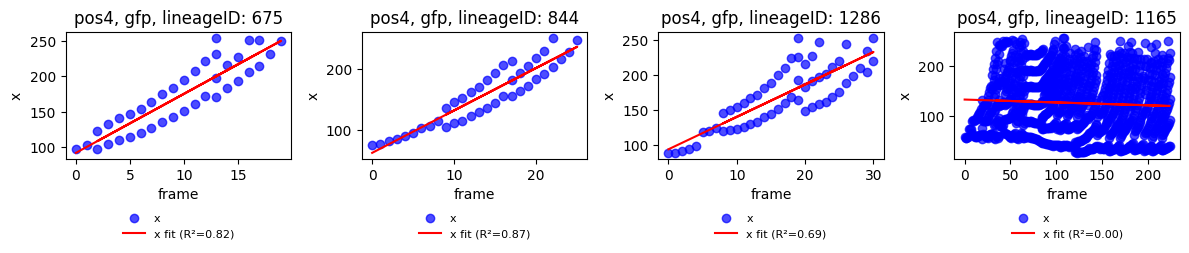

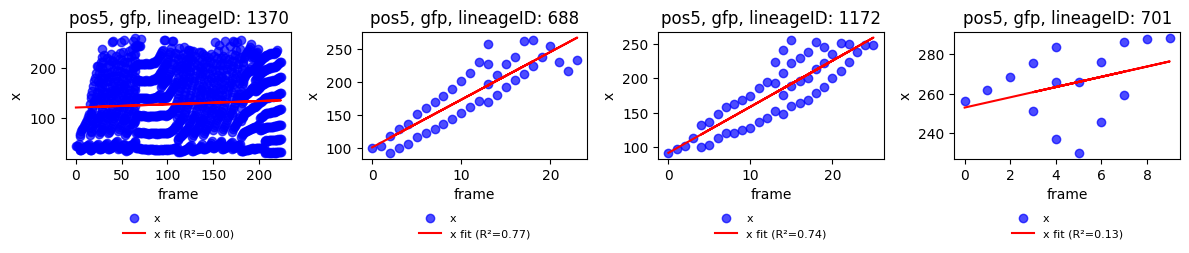

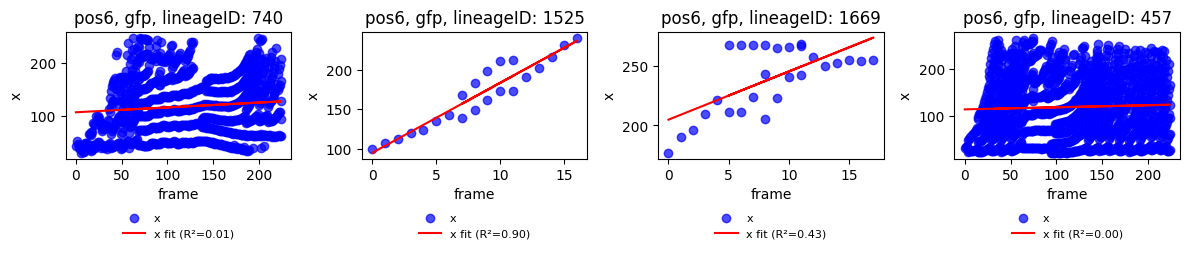

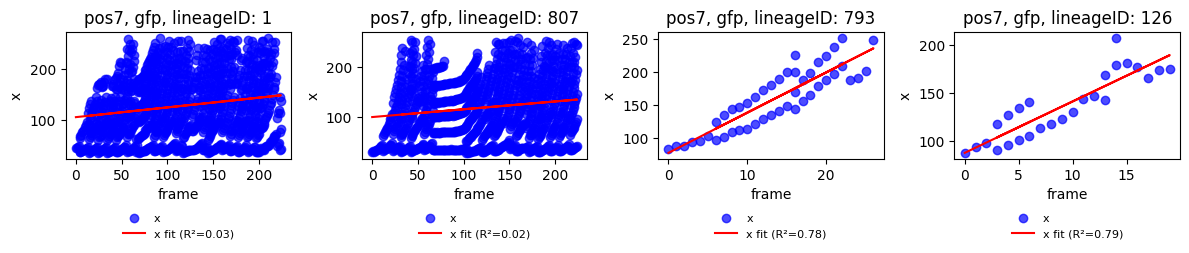

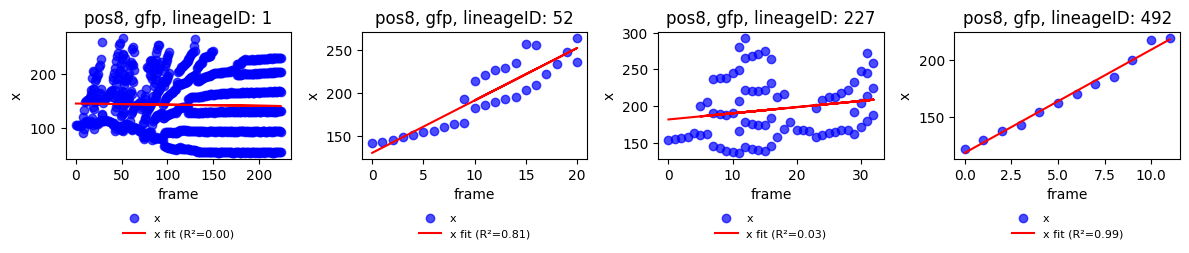

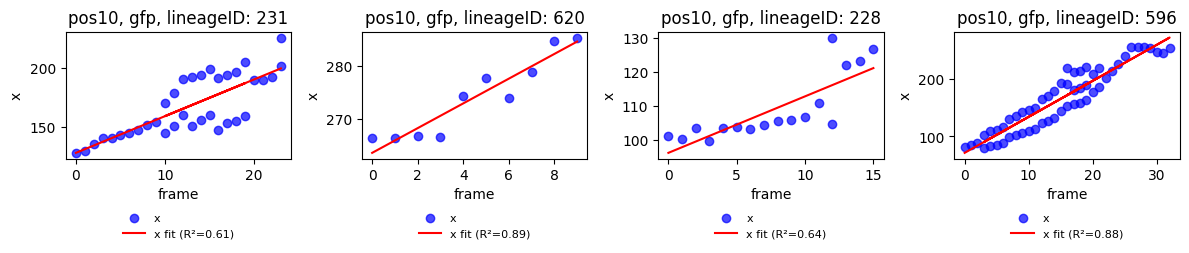

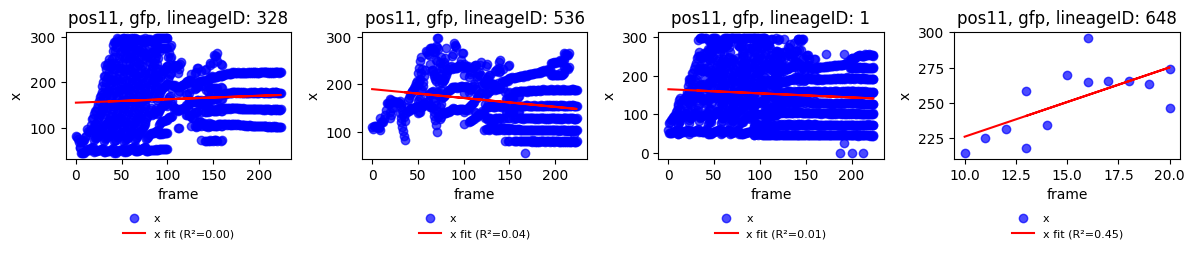

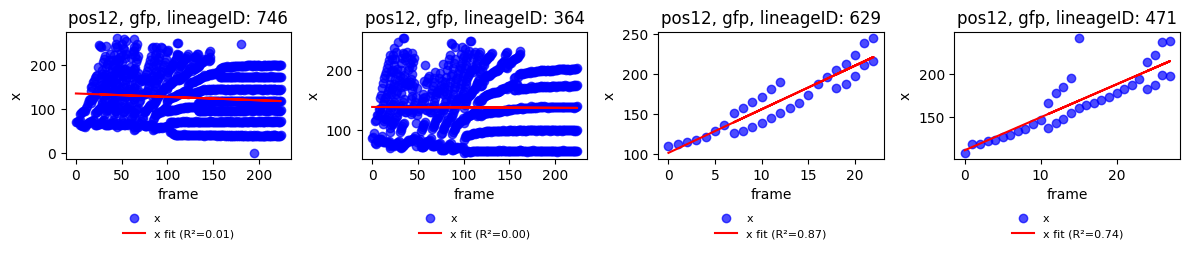

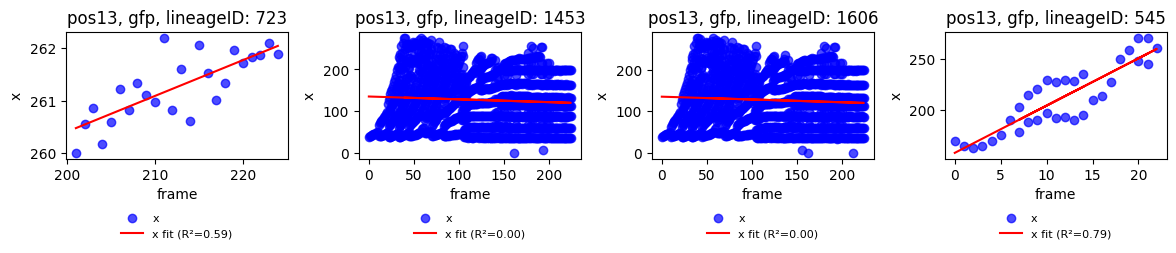

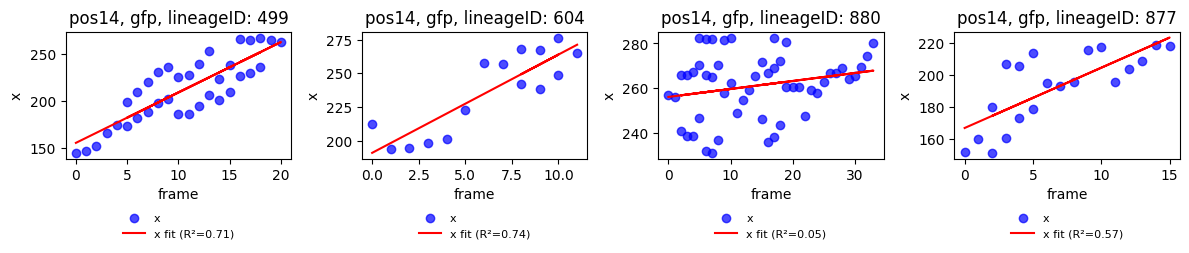

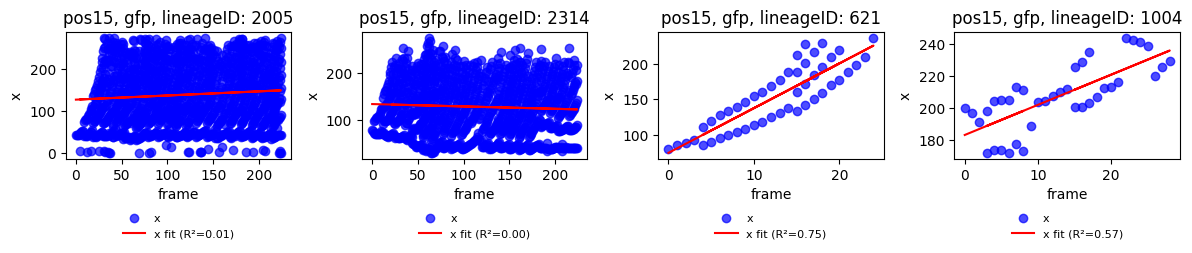

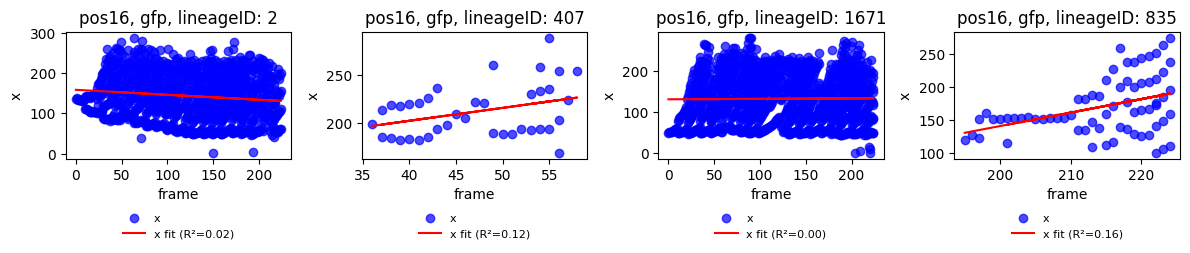

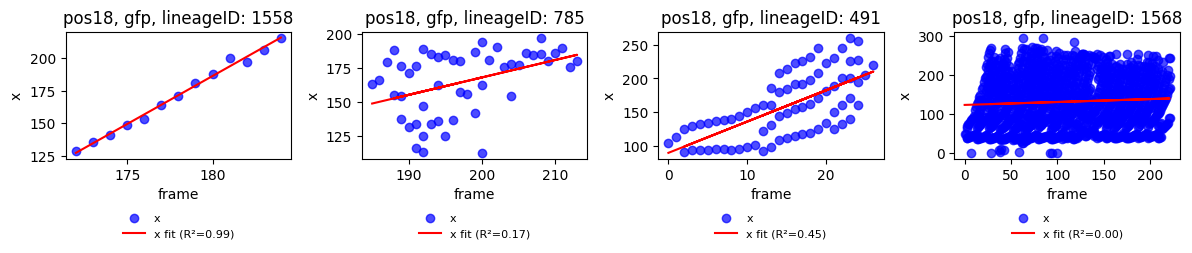

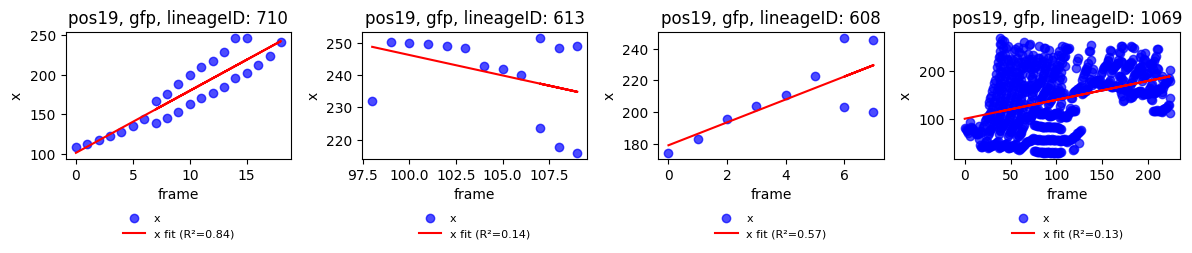

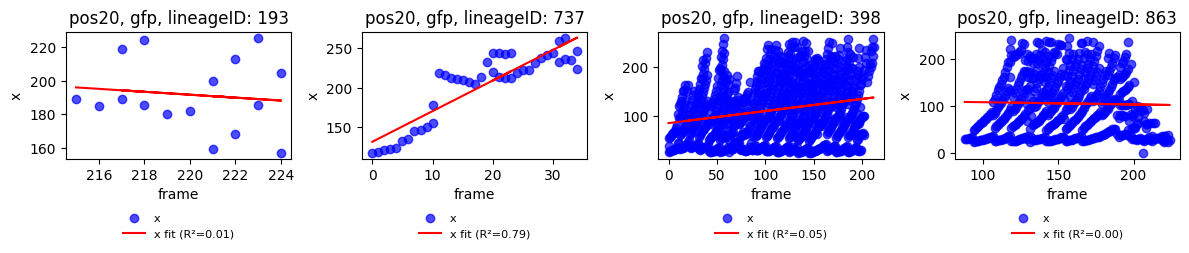

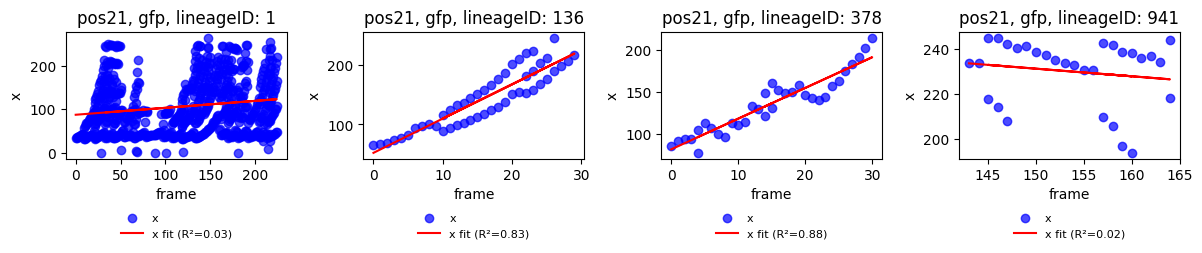

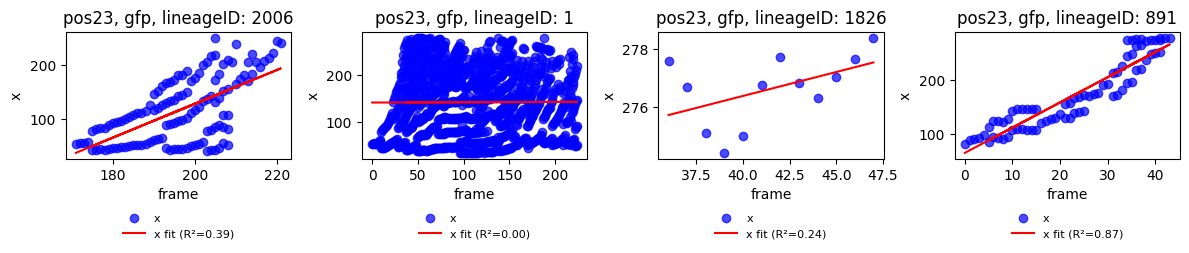

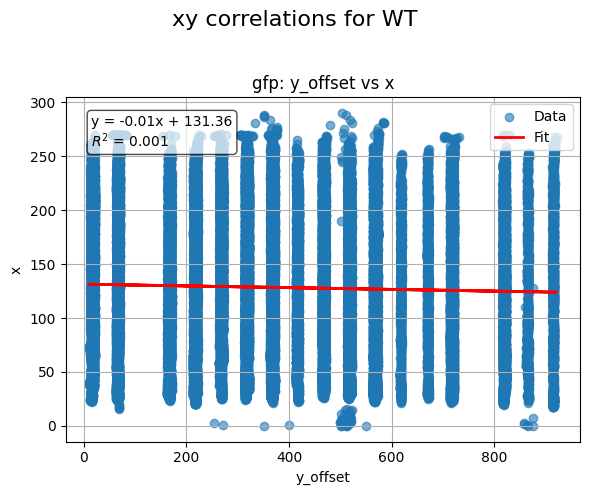

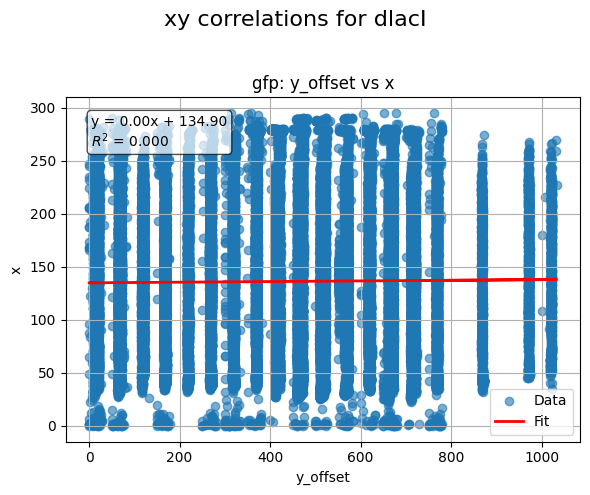

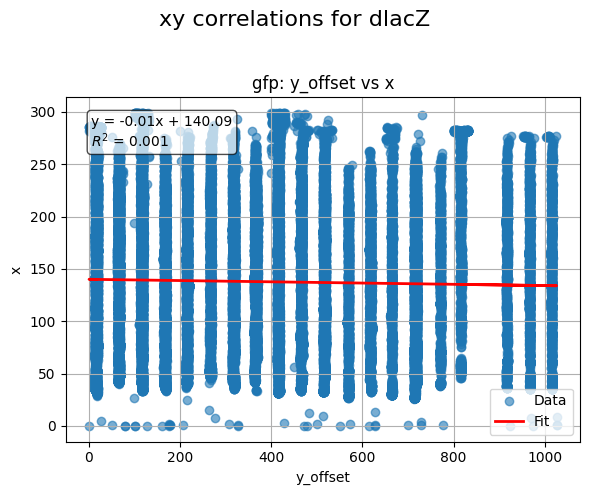

Calculating 'last_switch' as min of 'time_hour' within groups ('trackID', 'chamber')
Calculating 'next_switch' as max of 'time_hour' within groups ('trackID', 'chamber')
Calculating 'rank_by_x' by ranking 'x' within groups ('frame', 'chamber')


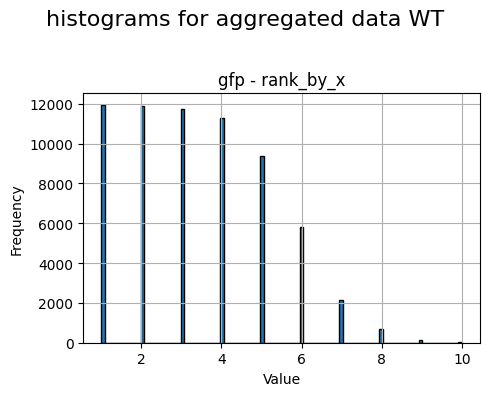

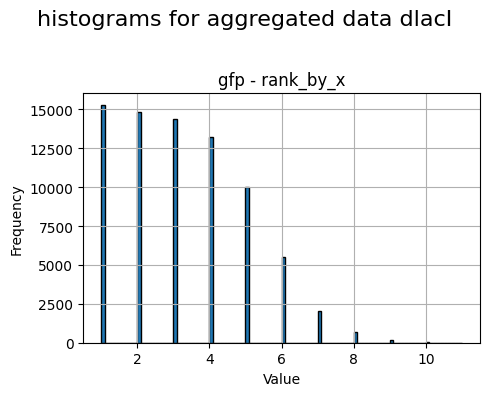

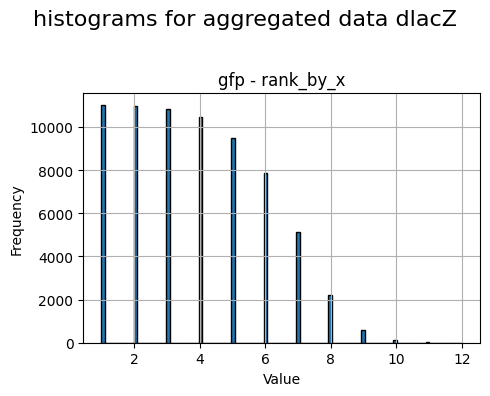

In [5]:
# ── QC: verify that low x = closed end ───────────────────────────────────────
# Lineages should drift from low to high x over time (growth toward open end).
# If the drift goes the other way, flip ascending=False in calculate_grouped_rank.
experiment.plot_qc(value_column="x", id_column=LINEAGE_COLUMN, n_samples=4)

# ── Cosmetic: spread chambers apart so the XY scatter is easier to read ──────
experiment.calculate_dataframe_operation(
    lambda df: df.assign(y_offset=df["y"] + df["chamber"] * CHAMBER_OFFSET)
)
experiment.plot_xy_correlation("y_offset", "x", group_by=GROUP_COLUMN) #remove group_by to plot each position individually for QC inspection

# ── Switch cycle boundaries ───────────────────────────────────────────────────
# Earliest and latest time_hour observed for each (trackID, chamber) combination
experiment.calculate_grouped_metric(
    group_columns=(ID_COLUMN, "chamber"),
    value_column="time_hour",
    mode="min",
    metric_column="last_switch",
)
experiment.calculate_grouped_metric(
    group_columns=(ID_COLUMN, "chamber"),
    value_column="time_hour",
    mode="max",
    metric_column="next_switch",
)

# Duration of the current expression state per row
experiment.calculate_dataframe_operation(
    lambda df: df.assign(switch_cycle_length=df["next_switch"] - df["last_switch"])
)

# Rank cells by x within each (frame, chamber) — rank 1 = lowest x = closed end
experiment.calculate_grouped_rank(
    group_columns=(FRAME_COLUMN, "chamber"),
    value_column="x",
    rank_column="rank_by_x",
    ascending=True,
)

# Inspect the distribution — top-pole cells should dominate at rank 1
experiment.plot_qc_histograms("rank_by_x", group_by=GROUP_COLUMN)

## 5 — Filter to top-pole cells and visualise dynamics

We create a **copy** of the fully processed experiment so the complete dataset
remains available for comparison. The copy is filtered to `rank_by_x == 1`,
keeping only the cell at the closed end of each chamber at every recorded frame.

A second length filter removes lineages that are too short within this spatial
subset — some lineages may no longer meet `MIN_OCCURENCES` after the spatial
subsetting reduces their frame count.

We then plot growth rate and switch cycle length for the top-pole subset alongside
the full dataset to assess whether pole position affects these quantities.

Filtering out rank_by_x with min value None and max value 1
Filtering channel gfp at position pos2:
Filtering channel gfp at position pos4:
Filtering channel gfp at position pos5:
Filtering channel gfp at position pos6:
Filtering channel gfp at position pos7:
Filtering channel gfp at position pos8:
Filtering channel gfp at position pos10:
Filtering channel gfp at position pos11:
Filtering channel gfp at position pos12:
Filtering channel gfp at position pos13:
Filtering channel gfp at position pos14:
Filtering channel gfp at position pos15:
Filtering channel gfp at position pos16:
Filtering channel gfp at position pos18:
Filtering channel gfp at position pos19:
Filtering channel gfp at position pos20:
Filtering channel gfp at position pos21:
Filtering channel gfp at position pos23:
Filtering out lineageID with less than 10 occurences
Filtering channel gfp at position pos2:
Filtering channel gfp at position pos4:
Filtering channel gfp at position pos5:
Filtering channel gfp at position p

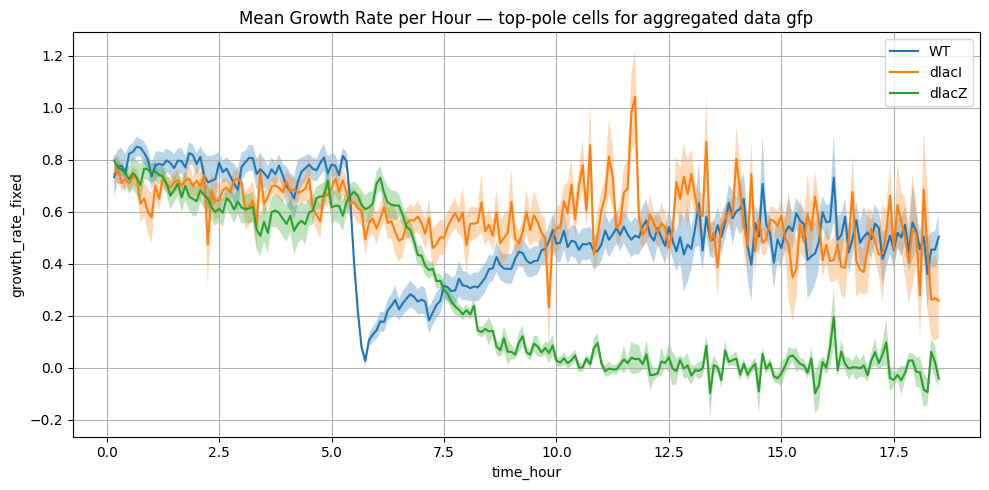

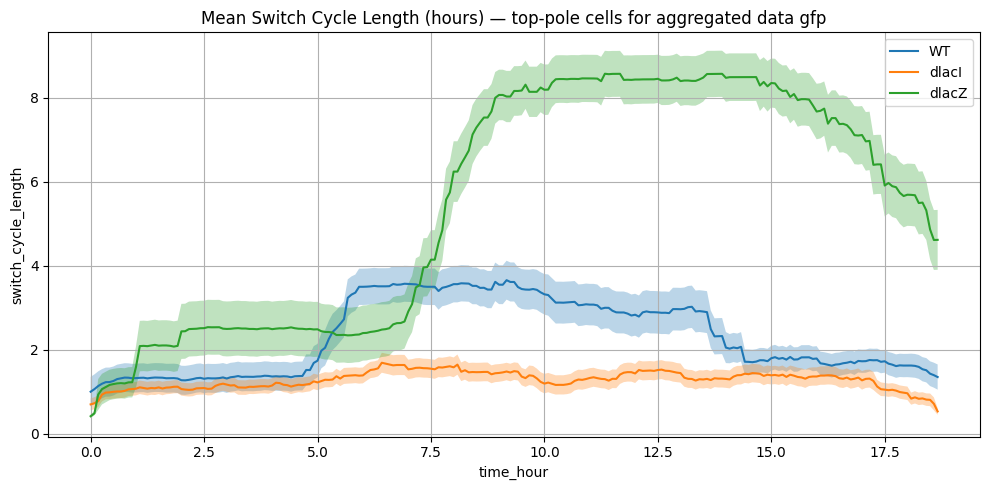

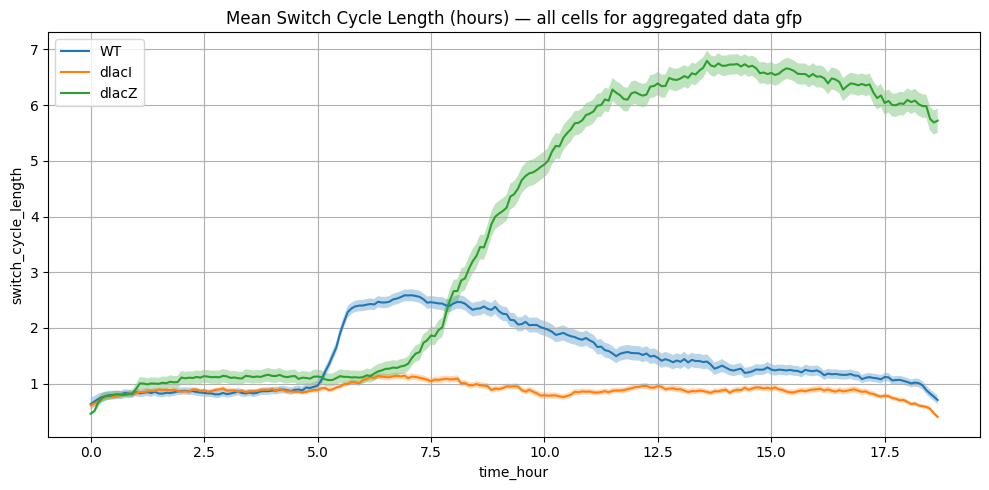

In [6]:
# Create a copy so the full dataset is still available for comparison
experiment_topcells = FluidExperiment.from_copy(experiment)

# Keep only the cell at the closed end of each chamber at every frame
experiment_topcells.filter_data(column="rank_by_x", max_value=1)

# Remove lineages that became too short after the spatial filter
experiment_topcells.filter_data(LINEAGE_COLUMN, min_occurences=MIN_OCCURENCES)

# Growth rate: top-pole cells
experiment_topcells.plot_rates(
    "growth_rate_fixed",
    group_by=GROUP_COLUMN, flip_grouping=True, frame_column="time_hour",
    title="Mean Growth Rate per Hour — top-pole cells",
)

# Switch cycle length — top-pole cells vs all cells
experiment_topcells.plot_rates(
    "switch_cycle_length",
    group_by="group", flip_grouping=True, frame_column="time_hour",
    title="Mean Switch Cycle Length (hours) — top-pole cells",
)
experiment.plot_rates(
    "switch_cycle_length",
    group_by="group", flip_grouping=True, frame_column="time_hour",
    title="Mean Switch Cycle Length (hours) — all cells",
)

## 6 — Survival analysis: time remaining until next switch

For each snapshot time in `START_TIMES` we ask:  
*Among the cells currently mid-cycle, how long do they take to reach their next switch event?*

### How `calculate_time_to_split` works
This method adds two new columns derived from the `time_hour` track boundaries:

| Column | Definition |
|--------|------------|
| `life_cycle_hours` | Total duration of this track in hours (`last_observation - first_observation`) |
| `time_to_split` | Hours remaining until this track ends (`last_observation - current_time_hour`) |

At any snapshot time `t`, the rows where `time_hour == t` come from exactly the cells
alive at `t`. The `time_to_split` value at those rows is the remaining duration of
the current expression state — no additional per-time-point filtering is needed.

### Three complementary views produced by `plot_time_to_split`

| `plot_types` value | What it shows |
|--------------------|---------------|
| `"boxplot"` | Duration distributions per group at each snapshot time, side by side with individual observations overlaid |
| `"division_curves"` | Fraction of cells that have not yet divided — one panel per snapshot time; a steeper drop means cells switch sooner |
| `"division_heatmap"` | 2-D compact view: rows = snapshot times, columns = duration bins, colour = fraction not yet switched; reveals systematic trends across the full experiment at a glance |

Calculating 'life_cycle_hours' and 'time_to_split' for 'trackID' using 'time_hour'


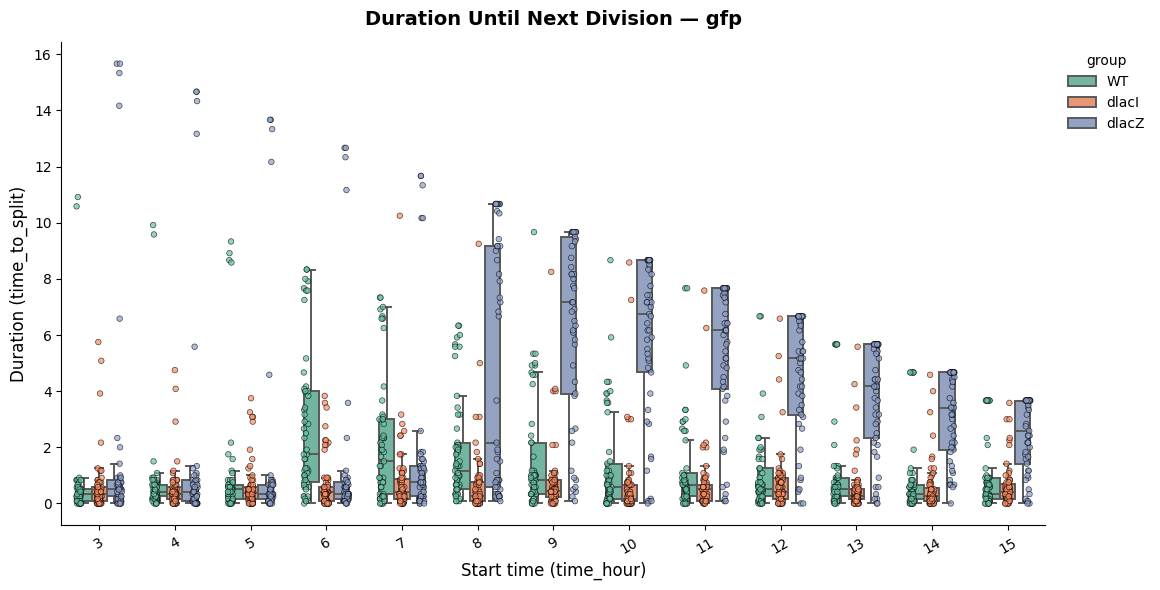

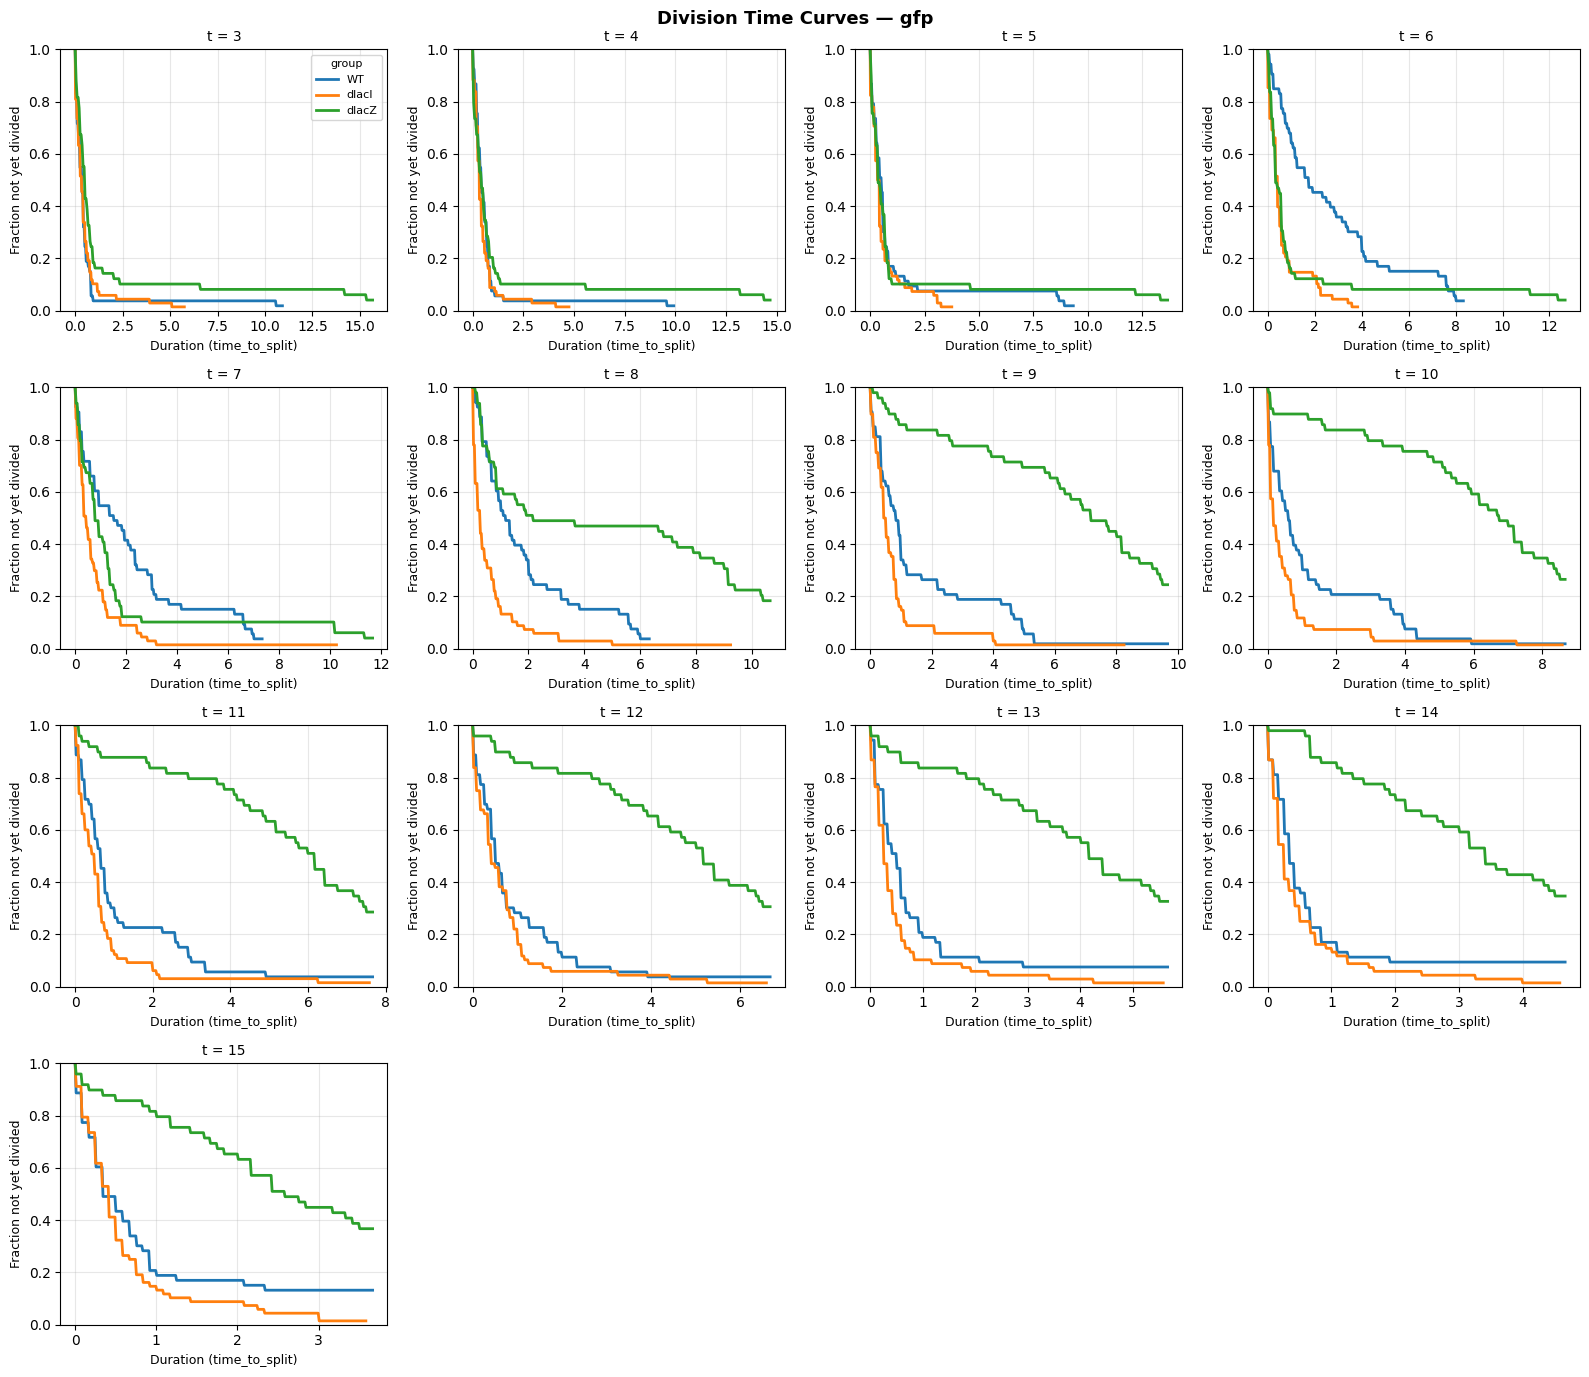

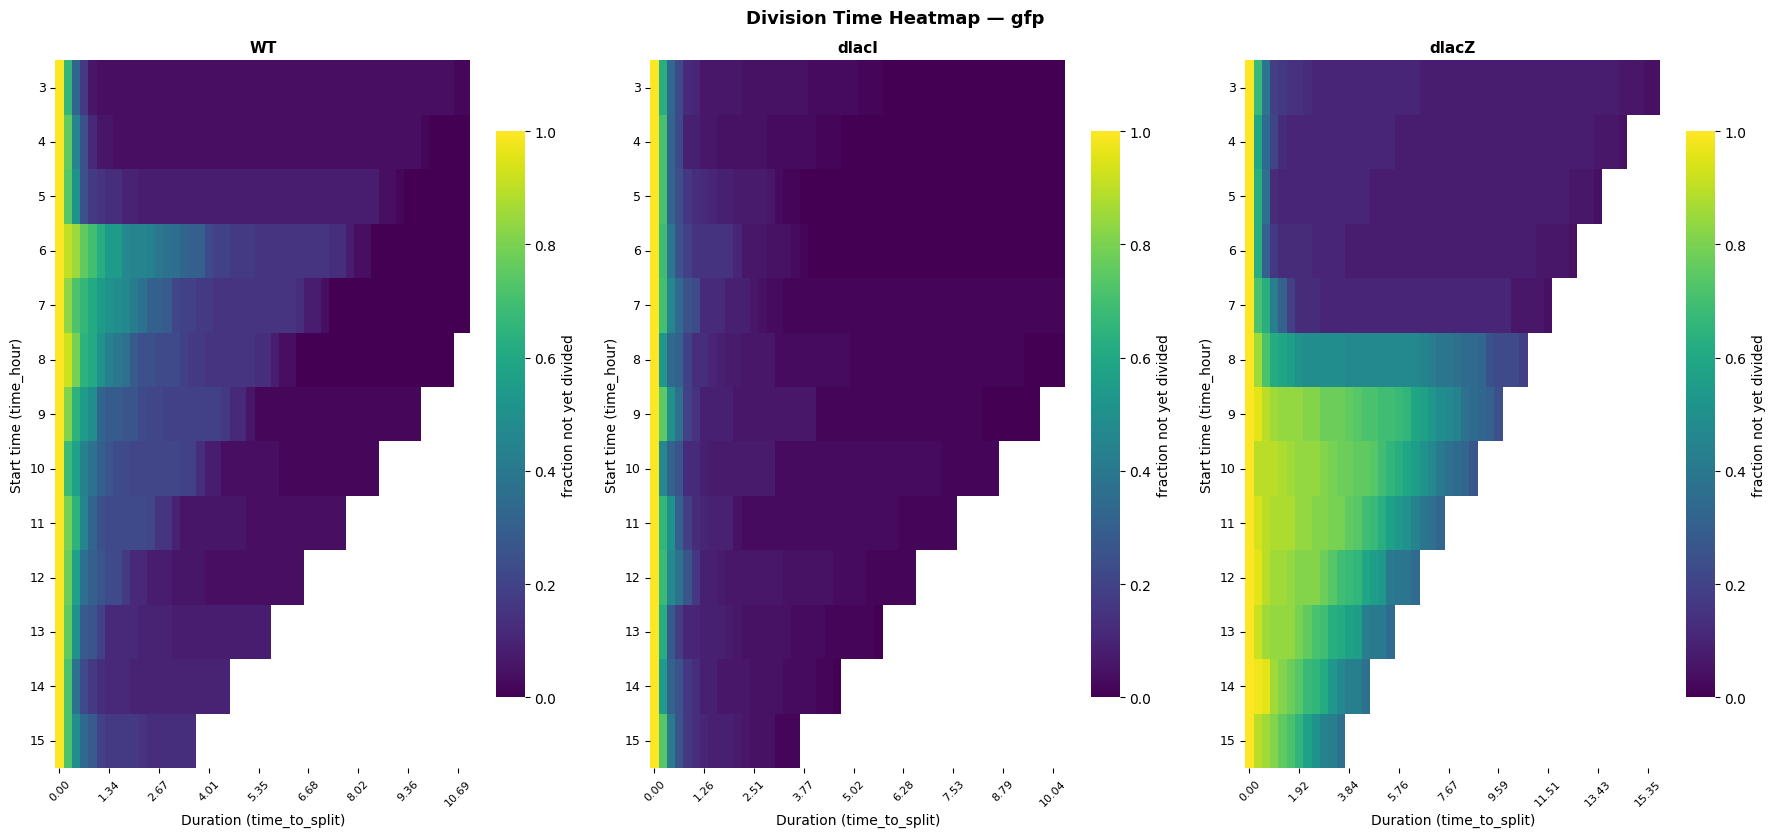

In [7]:
# Add time_to_split (remaining hours until this trackID ends = next switch event)
experiment_topcells.calculate_time_to_split(
    frame_column="time_hour",
    id_column=ID_COLUMN,
    life_cycle_column="life_cycle_hours",
    time_to_split_column="time_to_split",
)

# Plot duration distributions, survival curves, and heatmap across all snapshot times
experiment_topcells.plot_time_to_split(
    time_to_split_column="time_to_split",
    frame_column="time_hour",
    group_by=GROUP_COLUMN,
    flip_grouping=True,
    start_times=START_TIMES,
    plot_types=["boxplot", "division_curves", "division_heatmap"],
)

## 7 - Remove impaired baseline cells

Cells that were already alive for longer than `BASELINE_MAX_CYCLE` hours before the
medium switch are likely stalled or impaired — a healthy cell should have divided
at least once within that window. This applies to both:

- **Purely baseline tracks** that never divided before the switch
- **Spanning tracks** that were born long before the switch and are still alive at `BOUNDARY_TIME`

The filter uses the time each track spent *before* `BOUNDARY_TIME`
(`boundary_time − first_frame`), so tracks born just before the switch are unaffected.
Posterior tracks (born after the boundary) are never removed.

In [8]:
experiment_topcells_baseline_filtered = FluidExperiment.from_copy(experiment_topcells)

def _filter_long_baseline_tracks(df, boundary_time, max_cycle, frame_column):
    """Remove tracks that were alive for more than max_cycle before boundary_time.

    For each track, computes min(last_frame, boundary_time) - first_frame:
    - Purely baseline tracks: uses the full cycle duration
    - Spanning tracks: uses only the pre-boundary portion
    - Posterior tracks: negative value, never removed
    """
    import numpy as np
    grp = df.groupby(ID_COLUMN)[frame_column]
    track_first = grp.transform("min")
    track_last  = grp.transform("max")
    time_before_boundary = np.minimum(track_last, boundary_time) - track_first
    bad_ids = df.loc[time_before_boundary > max_cycle, ID_COLUMN].unique()
    filtered = df[~df[ID_COLUMN].isin(bad_ids)].reset_index(drop=True)
    summary = {
        "filter": "long_baseline_tracks",
        "boundary_time": boundary_time,
        "max_cycle": max_cycle,
        "removed_tracks": len(bad_ids),
        "rows_before": len(df),
        "rows_after": len(filtered),
    }
    return filtered, summary


experiment_topcells_baseline_filtered.filter_data(
    column=ID_COLUMN,
    custom_function=_filter_long_baseline_tracks,
    boundary_time=BOUNDARY_TIME,
    max_cycle=BASELINE_MAX_CYCLE,
    frame_column="time_hour",
)


Filtering channel gfp at position pos2:
Filtering channel gfp at position pos4:
Filtering channel gfp at position pos5:
Filtering channel gfp at position pos6:
Filtering channel gfp at position pos7:
Filtering channel gfp at position pos8:
Filtering channel gfp at position pos10:
Filtering channel gfp at position pos11:
Filtering channel gfp at position pos12:
Filtering channel gfp at position pos13:
Filtering channel gfp at position pos14:
Filtering channel gfp at position pos15:
Filtering channel gfp at position pos16:
Filtering channel gfp at position pos18:
Filtering channel gfp at position pos19:
Filtering channel gfp at position pos20:
Filtering channel gfp at position pos21:
Filtering channel gfp at position pos23:


## 8 — Lag time: deviation from baseline division timing

The **lag time** of a track is the difference between its actual switch-cycle duration
and the reference cycle duration derived from the same lineage during the **baseline period**
(all tracks that ended before `BOUNDARY_TIME`).

$$\text{lag\_time} = \text{life\_cycle\_hours} - \text{mean baseline cycle of lineage}$$

Baseline tracks scatter around zero by construction (their average deviation from
their own mean is exactly 0). Tracks after the switch will show positive lag if cells
take longer to divide than during baseline — a direct readout of how the medium switch
perturbs division timing.

Tracks in lineages with no baseline data receive `NaN` and are excluded from the plot.

### What the rate plot shows

`plot_rates` computes the **mean ± ribbon** of `lag_time` at each `time_hour` value.
Because `lag_time` is a per-track scalar broadcast to all rows of that track, the
y-axis reflects the average lag of tracks *alive at that moment* — revealing how
division timing drifts away from baseline as the experiment progresses.

Calculating 'lag_time' with boundary_time=5.0 (agg='mean', allow_negative=True)


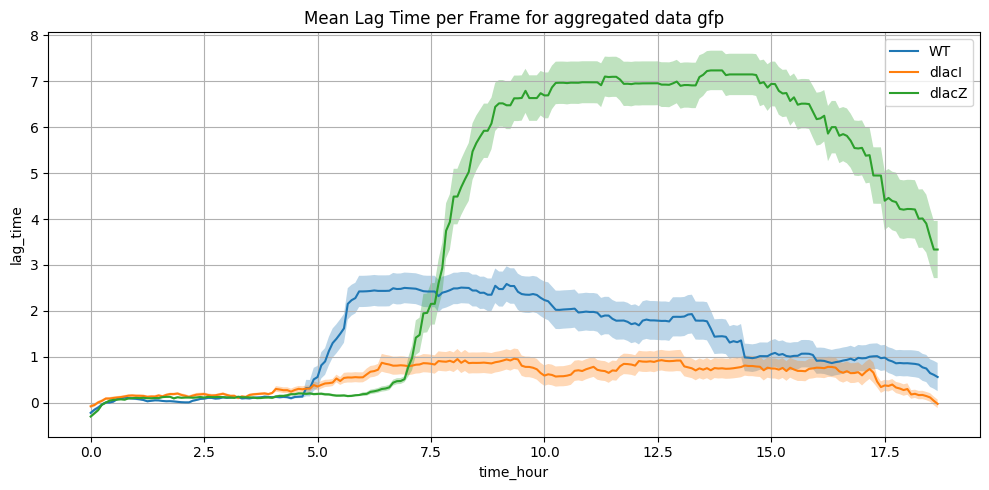

In [9]:
# Add lag_time column — deviation from per-lineage baseline cycle duration
experiment_topcells_baseline_filtered.calculate_lag_time(
    boundary_time=BOUNDARY_TIME,
    frame_column="time_hour",
    id_column=ID_COLUMN,
    lineage_column=LINEAGE_COLUMN,
    lag_time_column="lag_time",
    agg="mean",          # use "median" for a more robust baseline reference
    allow_negative=True, # set False to treat 0 as the minimum lag
)

# Plot mean lag time over the course of the experiment, grouped by condition
experiment_topcells_baseline_filtered.plot_rates(
    rate_column="lag_time",
    frame_column="time_hour",
    group_by="group",
    flip_grouping=True,
    title="Mean Lag Time per Frame",
)

### Recreate Time until Division Plots for baseline filtered data

After removing all cells that are inactive during baseline conditions, we can again recreate the Division plots, now with less noise

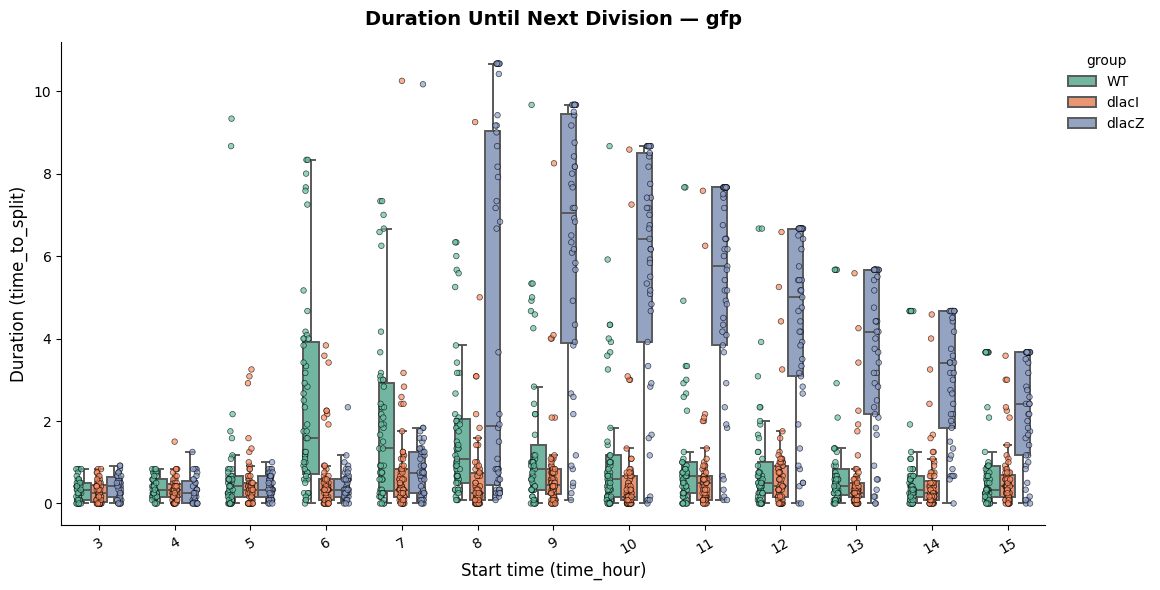

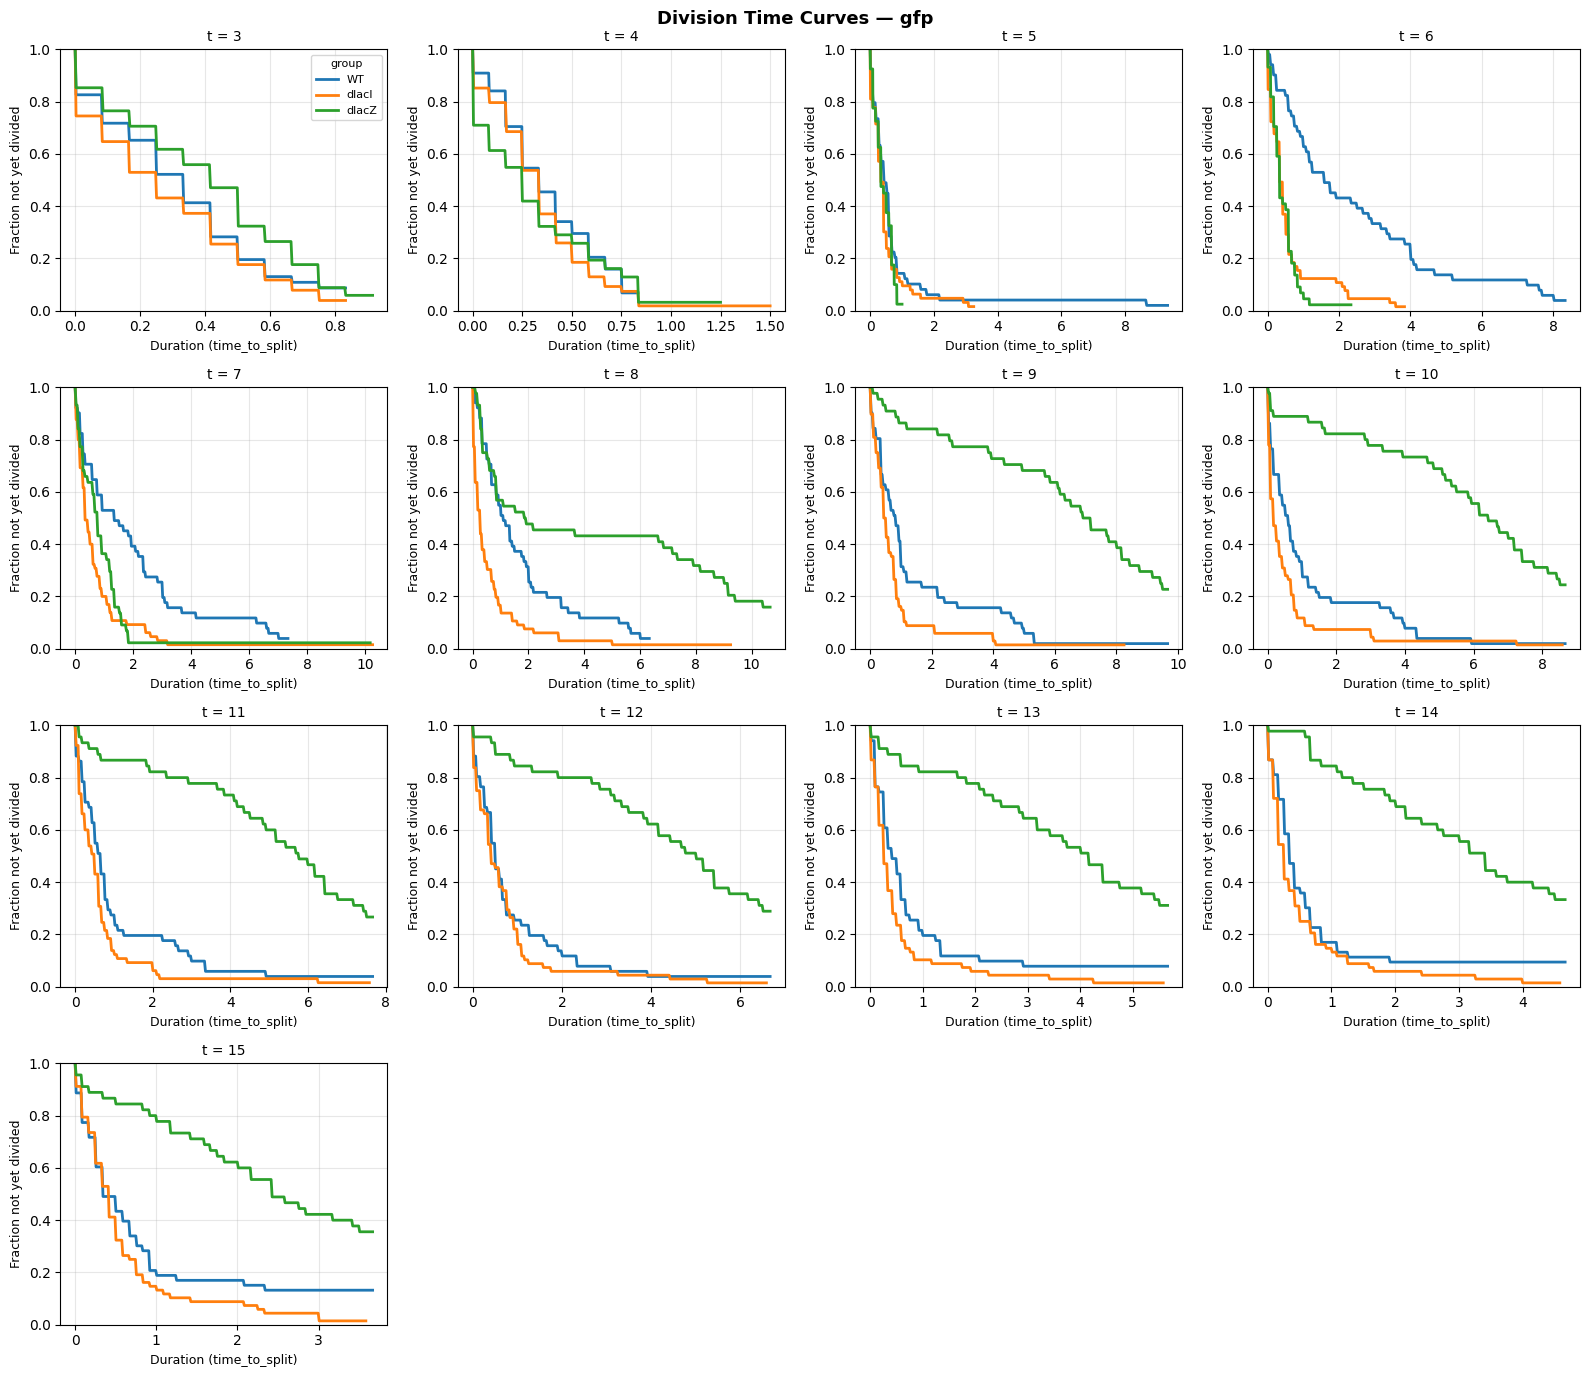

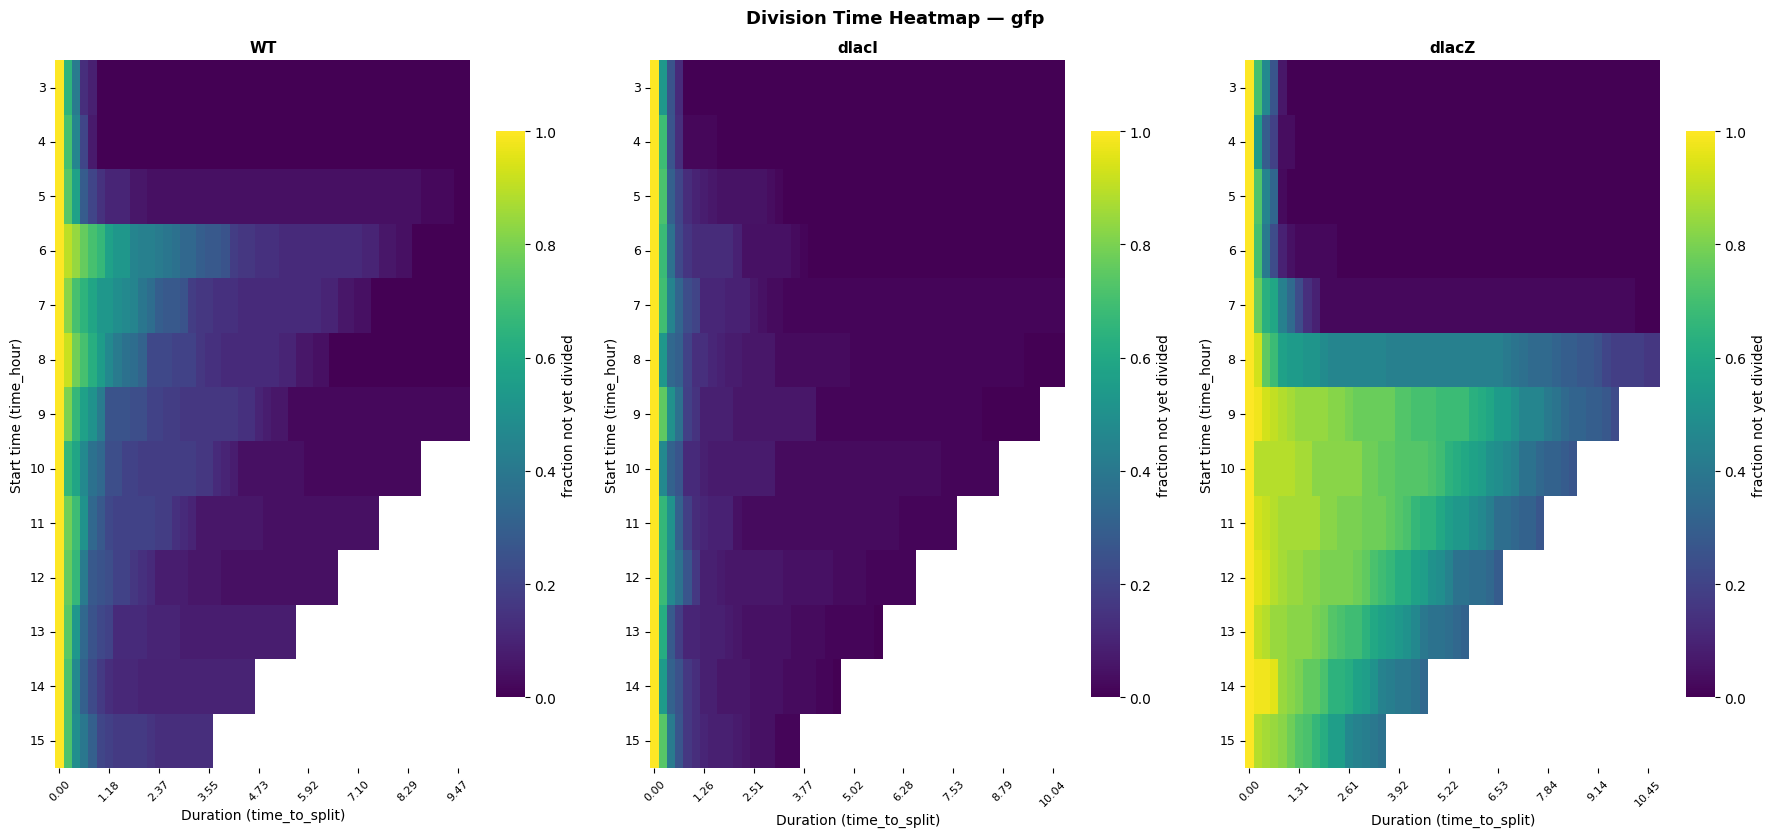

In [10]:
# Plot duration distributions, survival curves, and heatmap across all snapshot times
experiment_topcells_baseline_filtered.plot_time_to_split(
    time_to_split_column="time_to_split",
    frame_column="time_hour",
    group_by=GROUP_COLUMN,
    flip_grouping=True,
    start_times=START_TIMES,
    plot_types=["boxplot", "division_curves", "division_heatmap"],
)

### Lets also inspect the filter history to see how much data was removed in each step

below is the filter history for all steps at each position / color channel. the document is finished here

In [11]:
experiment_topcells_baseline_filtered.report_filter_history()

Filtering applied to color channel gfp at position pos2:
Number of filters applied: 4
Filter 1:
	column_filtered: lineageID
	min_occurences: 10
	min_value: 
	max_value: 
	max_occurences: 
	unique_values_before: 100
	unique_values_after: 44
	rows_before: 15134
	rows_after: 14966
	filter_rate_rows: 1
	filter_rate_unique_values: 56
Filter 2:
	column_filtered: rank_by_x
	min_occurences: 0
	min_value: 
	max_value: 1
	max_occurences: 
	unique_values_before: 10
	unique_values_after: 1
	rows_before: 14966
	rows_after: 2700
	filter_rate_rows: 81
	filter_rate_unique_values: 90
Filter 3:
	column_filtered: lineageID
	min_occurences: 10
	min_value: 
	max_value: 
	max_occurences: 
	unique_values_before: 13
	unique_values_after: 13
	rows_before: 2700
	rows_after: 2700
	filter_rate_rows: 0
	filter_rate_unique_values: 0
Filter 4:
	filter: long_baseline_tracks
	boundary_time: 5.0
	max_cycle: 1.0
	removed_tracks: 4
	rows_before: 2700
	rows_after: 2476


Filtering applied to color channel gfp at position 